# Multi-Factor Portfolio Research Framework — Indian Equities
## Notebook 02 — Factor Research *(v2 — revised factor model)*

**Inputs:** `data/raw_prices.csv`, `data/daily_returns.csv`, `data/benchmark_nifty50.csv`,
`data/amfi_membership_matrix.csv`, `data/ticker_resolution_log.csv`, `data/study_window.json`
(all from Notebook 01)
**Output:** a long-format, point-in-time-safe factor panel — one composite score per
`(rebalance_date, ticker)` — ready for Notebook 03 to rank, select, and weight.

---

## Objective

Construct a point-in-time-safe, price/return-only multi-factor composite score for every ticker in the
Notebook 01 universe, at monthly granularity, for Notebook 03 to rank and select against.

## Research Questions Addressed

This notebook establishes the factor model whose out-of-sample performance the remaining notebooks
evaluate; it does not itself test whether the factor model produces outperformance (Notebooks 04–05
address that). It resolves two design questions: which four factors constitute the composite score,
and how lookback windows, scoring direction, and weights are set without reference to backtest
performance.

## Revision History: v1 to v2

The original design included Quality (ROE/ROA/Margin) and Value (P/E/P/B/EV-EBITDA) factors, which
required point-in-time company fundamentals. In practice, yfinance's quarterly financials expose only a
limited trailing window (typically the last 4–8 reported quarters as of the query date) rather than a
historical point-in-time database, producing structurally poor factor coverage for most of the
backtest window. The revised model replaces Quality and Value with Maximum Drawdown and Beta, both
computed purely from price/return data. This removes the yfinance-fundamentals dependency entirely —
no per-ticker API calls, no point-in-time as-of joins — and restores full factor coverage across the
backtest window rather than only its recent portion.

## Locked Factor Model (v2)

| Factor | Lookback | Direction | Weight | Role |
|---|---:|---|---:|---|
| Momentum | 252d (12-1 month) | Higher is better | 40% | Alpha generation |
| Low Volatility | 252d | Lower is better | 20% | Risk control |
| Maximum Drawdown | 756d (~3yr) | Smaller (less negative) drawdown is better | 20% | Tail-risk control |
| Beta | 756d (~3yr) | Closest to 1.0 is best | 20% | Market exposure control |

Momentum and Low Volatility are unchanged from v1. Maximum Drawdown and Beta are new and both use a
756-trading-day (~3-year) lookback — a more suitable window for tail-risk and systematic-exposure
estimation than a single year.

## Assumptions

- The 756-day Maximum Drawdown/Beta lookback requires Notebook 01's `WARMUP_START` to begin
  2015-07-01 (moved back from 2017-07-01) so a full 3-year trailing window is available at the first
  backtest rebalance date (2018-07-01); `BACKTEST_START` itself is unchanged.
- Beta is scored for closeness to 1.0, not for being minimal: `beta_distance = -|beta - 1.0|`, then
  z-scored cross-sectionally like every other factor, so a higher score uniformly means "better"
  across all four factors.
- All four factors are computed using only price/return data up to and including each rebalance date,
  by construction — none can observe the future. Trailing windows are position-based against the price
  panel's own trading-day index, not calendar-day arithmetic.
- Factors are computed at every month-end trading date from `BACKTEST_START` onward — the finest
  granularity needed across Notebook 03's rebalancing-frequency experiments (monthly, quarterly,
  semi-annual).

## Environment Setup

This notebook has no yfinance dependency: v2 is computed entirely from Notebook 01's price/return
output, since Quality and Value (the two factors that required fundamentals) were removed.

In [1]:
!pip install pandas numpy matplotlib scipy --quiet
print('Packages ready. (yfinance is no longer needed in this notebook -- v2 is price/return-only.)')


Packages ready. (yfinance is no longer needed in this notebook -- v2 is price/return-only.)



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: C:\Users\vidya\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


### Configuration: Factor Parameters (v2, Locked)

Defines the four lookback windows, the Beta target (1.0), the locked 40/20/20/20 factor weight
allocation (asserted to sum to 1.0), the winsorisation clip (`Z_CLIP = 3.0`), and the month-end
rebalance grid frequency. The dark-theme visual configuration is copied verbatim from Notebook 01.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import os
import json

warnings.filterwarnings('ignore')

BASE_DIR   = '.'
DATA_DIR   = os.path.join(BASE_DIR, 'data')
OUTPUT_DIR = os.path.join(BASE_DIR, 'output')
os.makedirs(DATA_DIR,   exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ══════════════════════════════════════════════════════════════════════════════
#  ▶▶  FACTOR PARAMETERS (v2 -- locked)  ◀◀
# ══════════════════════════════════════════════════════════════════════════════
MOM_LOOKBACK_DAYS   = 252   # ~12 months of trading days
MOM_SKIP_DAYS       = 21    # ~1 month skipped (avoids short-term reversal) -- 12-1 momentum
VOL_LOOKBACK_DAYS   = 252   # ~12 months trailing daily-return window for Low Volatility
MAXDD_LOOKBACK_DAYS = 756   # ~3 years -- tail-risk window for Maximum Drawdown
BETA_LOOKBACK_DAYS  = 756   # ~3 years -- systematic-exposure window for Beta
BETA_TARGET         = 1.0   # Beta is scored for closeness to this value, not for being minimal

FACTOR_WEIGHTS = {
    'momentum': 0.40,
    'low_vol':  0.20,
    'max_dd':   0.20,
    'beta':     0.20,
}
assert abs(sum(FACTOR_WEIGHTS.values()) - 1.0) < 1e-9, 'Factor weights must sum to 1.0'

Z_CLIP = 3.0   # winsorise cross-sectional z-scores at +/- this many std devs before averaging

REBALANCE_GRID_FREQ = 'ME'   # month-end -- the finest grid; NB03 subsets this for quarterly/semi-annual

ANN_FACTOR = 252

# -- Visual style: identical to Notebook 01, reused across the whole project ---
DARK_BG    = '#0D0D0D'
PANEL_BG   = '#1A1A1A'
COLORS     = ['#29B6F6', '#FF7043', '#66BB6A', '#CE93D8', '#FFB300',
              '#F48FB1', '#80DEEA', '#FFCC02', '#A5D6A7', '#EF9A9A']
ACCENT     = '#00FF88'
ACCENT2    = '#FF5252'
GRID_COLOR = '#2A2A2A'
TEXT_COLOR = '#E0E0E0'

plt.rcParams.update({
    'figure.facecolor': DARK_BG,   'axes.facecolor':  DARK_BG,
    'savefig.facecolor': DARK_BG,
    'axes.edgecolor':   GRID_COLOR, 'axes.labelcolor': TEXT_COLOR,
    'xtick.color':      TEXT_COLOR, 'ytick.color':     TEXT_COLOR,
    'text.color':       TEXT_COLOR, 'grid.color':      GRID_COLOR,
    'grid.linestyle':   '--',       'grid.alpha':      0.4,
    'font.family':      'monospace',
    'legend.facecolor': PANEL_BG,  'legend.edgecolor': GRID_COLOR,
})

print('Configuration loaded (v2 factor model).')
print(f'  Momentum        : {MOM_LOOKBACK_DAYS}d lookback, {MOM_SKIP_DAYS}d skip (12-1 momentum)   | weight {FACTOR_WEIGHTS["momentum"]:.0%}')
print(f'  Low Volatility  : {VOL_LOOKBACK_DAYS}d trailing annualised vol                          | weight {FACTOR_WEIGHTS["low_vol"]:.0%}')
print(f'  Maximum Drawdown: {MAXDD_LOOKBACK_DAYS}d (~3yr) trailing max drawdown                    | weight {FACTOR_WEIGHTS["max_dd"]:.0%}')
print(f'  Beta            : {BETA_LOOKBACK_DAYS}d (~3yr) trailing, scored for closeness to {BETA_TARGET} | weight {FACTOR_WEIGHTS["beta"]:.0%}')


Configuration loaded (v2 factor model).
  Momentum        : 252d lookback, 21d skip (12-1 momentum)   | weight 40%
  Low Volatility  : 252d trailing annualised vol                          | weight 20%
  Maximum Drawdown: 756d (~3yr) trailing max drawdown                    | weight 20%
  Beta            : 756d (~3yr) trailing, scored for closeness to 1.0 | weight 20%


### Load Notebook 01 Outputs

Loads prices, returns, the NIFTY 50 benchmark, the master universe list, and the study window
parameters. Prints the warm-up length in years and raises an explicit warning if it is shorter than
~3 years, which would indicate a stale Notebook 01 run predating the `WARMUP_START` change to
2015-07-01.

In [3]:
prices    = pd.read_csv(os.path.join(DATA_DIR, 'raw_prices.csv'),  index_col=0, parse_dates=True)
returns   = pd.read_csv(os.path.join(DATA_DIR, 'daily_returns.csv'), index_col=0, parse_dates=True)
benchmark = pd.read_csv(os.path.join(DATA_DIR, 'benchmark_nifty50.csv'), index_col=0, parse_dates=True).iloc[:, 0]
benchmark_returns = benchmark.pct_change()

master_universe = pd.read_csv(os.path.join(DATA_DIR, 'master_universe.csv'))['ticker'].tolist()

with open(os.path.join(DATA_DIR, 'study_window.json'), 'r') as f:
    _sw = json.load(f)
WARMUP_START   = _sw.get('warmup_start',   '2015-07-01')
BACKTEST_START = _sw.get('backtest_start', '2018-07-01')
END_DATE       = _sw.get('end_date',       prices.index[-1].strftime('%Y-%m-%d'))

print(f'Prices    shape : {prices.shape}')
print(f'Returns   shape : {returns.shape}')
print(f'Benchmark shape : {benchmark.shape}  ({benchmark.index[0].date()} -> {benchmark.index[-1].date()})')
print(f'Master universe : {len(master_universe)} tickers')
print(f'Study window    : warm-up {WARMUP_START} / backtest {BACKTEST_START} -> {END_DATE}')

_warmup_days = (pd.Timestamp(BACKTEST_START) - pd.Timestamp(WARMUP_START)).days
print(f'\nWarm-up length: {_warmup_days} calendar days (~{_warmup_days/365.25:.1f} years) '
      f'-- needs to be >= ~3 years for the 756-day Max Drawdown/Beta lookback to be usable '
      f'at the first backtest rebalance date.')
if _warmup_days < 756 / 252 * 365.25 * 0.95:
    print('WARNING: warm-up window looks shorter than ~3 years -- did you re-run the updated '
          'Notebook 01 (WARMUP_START should be 2015-07-01)? Early rebalance dates may lack '
          'sufficient history for Max Drawdown / Beta.')


Prices    shape : (2755, 404)
Returns   shape : (2755, 404)
Benchmark shape : (2718,)  (2015-07-01 -> 2026-07-15)
Master universe : 404 tickers
Study window    : warm-up 2015-07-01 / backtest 2018-07-01 -> 2026-07-16

Warm-up length: 1096 calendar days (~3.0 years) -- needs to be >= ~3 years for the 756-day Max Drawdown/Beta lookback to be usable at the first backtest rebalance date.


### Build the Monthly Rebalance-Date Grid

Factors are computed at every month-end trading date from `BACKTEST_START` onward — the finest
granularity needed across all rebalancing-frequency experiments in Notebook 03.

In [4]:
all_trading_dates = prices.index.sort_values()
bt_dates = all_trading_dates[all_trading_dates >= pd.Timestamp(BACKTEST_START)]

month_end_flags = bt_dates.to_series().groupby(bt_dates.to_period('M')).tail(1)
REBALANCE_DATES = pd.DatetimeIndex(sorted(month_end_flags.values))

print(f'Rebalance grid (month-end trading dates): {len(REBALANCE_DATES)}')
print(f'  First : {REBALANCE_DATES[0].date()}')
print(f'  Last  : {REBALANCE_DATES[-1].date()}')


Rebalance grid (month-end trading dates): 97
  First : 2018-07-31
  Last  : 2026-07-15


### Momentum Factor (12-1 Month, Price-Based)

Unchanged from v1. Point-in-time-safe by construction: at rebalance date $t$, only price data up to and
including $t$ is used. This is the Jegadeesh–Titman 12-1 momentum specification, skipping the most
recent month to avoid short-term reversal effects:

$$\text{momentum}(t) = \frac{P_{t-\text{skip}}}{P_{t-\text{skip}-\text{lookback}}} - 1$$

with lookback = 252 trading days and skip = 21 trading days.

In [5]:
def compute_momentum_panel(prices_df, rebalance_dates, lookback=MOM_LOOKBACK_DAYS, skip=MOM_SKIP_DAYS):
    idx = prices_df.index
    pos_of_date = {d: i for i, d in enumerate(idx)}
    out = pd.DataFrame(index=rebalance_dates, columns=prices_df.columns, dtype=float)

    for rd in rebalance_dates:
        if rd not in pos_of_date:
            continue
        pos_t     = pos_of_date[rd]
        pos_skip  = pos_t - skip
        pos_start = pos_t - skip - lookback
        if pos_start < 0 or pos_skip < 0:
            continue
        p_end   = prices_df.iloc[pos_skip]
        p_start = prices_df.iloc[pos_start]
        out.loc[rd] = (p_end / p_start) - 1.0

    return out


momentum_panel = compute_momentum_panel(prices, REBALANCE_DATES)
print(f'Momentum panel shape: {momentum_panel.shape}')
print(f'Coverage, first rebalance date : {momentum_panel.iloc[0].notna().sum()} / {momentum_panel.shape[1]}')
print(f'Coverage, last  rebalance date : {momentum_panel.iloc[-1].notna().sum()} / {momentum_panel.shape[1]}')


Momentum panel shape: (97, 404)
Coverage, first rebalance date : 297 / 404
Coverage, last  rebalance date : 389 / 404


### Low Volatility Factor (Trailing 252-Day Annualised Vol)

Unchanged from v1. Raw output is volatility itself (higher = more volatile); sign is inverted during
normalisation (Cell 10) so that, consistent with every other factor, a higher score always means
"better":

$$\text{vol}(t) = \text{std}(r_{t-251}, \dots, r_t) \times \sqrt{252}$$

In [6]:
def compute_lowvol_panel(returns_df, rebalance_dates, lookback=VOL_LOOKBACK_DAYS):
    idx = returns_df.index
    pos_of_date = {d: i for i, d in enumerate(idx)}
    out = pd.DataFrame(index=rebalance_dates, columns=returns_df.columns, dtype=float)

    for rd in rebalance_dates:
        if rd not in pos_of_date:
            continue
        pos_t     = pos_of_date[rd]
        pos_start = pos_t - lookback + 1
        if pos_start < 0:
            continue
        window = returns_df.iloc[pos_start:pos_t + 1]
        if len(window) < lookback * 0.8:
            continue
        out.loc[rd] = window.std() * np.sqrt(ANN_FACTOR)

    return out


lowvol_panel = compute_lowvol_panel(returns, REBALANCE_DATES)
print(f'Low-Vol panel shape: {lowvol_panel.shape}')
print(f'Coverage, first rebalance date : {lowvol_panel.iloc[0].notna().sum()} / {lowvol_panel.shape[1]}')
print(f'Coverage, last  rebalance date : {lowvol_panel.iloc[-1].notna().sum()} / {lowvol_panel.shape[1]}')


Low-Vol panel shape: (97, 404)
Coverage, first rebalance date : 320 / 404
Coverage, last  rebalance date : 404 / 404


### Maximum Drawdown Factor (Trailing 756-Day / ~3-Year)

For each rebalance date, computes the worst peak-to-trough decline over the trailing 3-year price
window:

$$\text{running\_max}(t') = \max_{\tau \le t'} P_\tau, \qquad
\text{drawdown}(t') = \frac{P_{t'}}{\text{running\_max}(t')} - 1$$
$$\text{max\_drawdown}(t) = \min_{t' \in [t-755,\, t]} \text{drawdown}(t')$$

Expressed as a negative number (e.g., $-0.35$ for a 35% drawdown), a value closer to zero (a smaller
drawdown) is better — no sign inversion is required before z-scoring, unlike Low Volatility.

In [7]:
def compute_maxdd_panel(prices_df, rebalance_dates, lookback=MAXDD_LOOKBACK_DAYS):
    idx = prices_df.index
    pos_of_date = {d: i for i, d in enumerate(idx)}
    out = pd.DataFrame(index=rebalance_dates, columns=prices_df.columns, dtype=float)

    for rd in rebalance_dates:
        if rd not in pos_of_date:
            continue
        pos_t     = pos_of_date[rd]
        pos_start = pos_t - lookback + 1
        if pos_start < 0:
            continue
        window = prices_df.iloc[pos_start:pos_t + 1]
        valid_frac = window.notna().mean()

        running_max = window.cummax()
        drawdown = window / running_max - 1.0
        maxdd = drawdown.min()
        maxdd[valid_frac < 0.8] = np.nan   # require at least 80% of the window populated

        out.loc[rd] = maxdd

    return out


maxdd_panel = compute_maxdd_panel(prices, REBALANCE_DATES)
print(f'Max Drawdown panel shape: {maxdd_panel.shape}')
print(f'Coverage, first rebalance date : {maxdd_panel.iloc[0].notna().sum()} / {maxdd_panel.shape[1]}')
print(f'Coverage, last  rebalance date : {maxdd_panel.iloc[-1].notna().sum()} / {maxdd_panel.shape[1]}')
print(f'Median max drawdown across universe, last rebalance date: {maxdd_panel.iloc[-1].median():.1%}')


Max Drawdown panel shape: (97, 404)
Coverage, first rebalance date : 280 / 404
Coverage, last  rebalance date : 375 / 404
Median max drawdown across universe, last rebalance date: -40.6%


### Beta Factor (Trailing 756-Day / ~3-Year, vs. NIFTY 50)

Rolling beta of each stock's daily returns against NIFTY 50 daily returns, using pairwise-complete
covariance (`Series.cov`, which aligns on overlapping non-null dates automatically, avoiding discarding
the full window over a few missing days):

$$\beta(t) = \frac{\text{Cov}(r_{\text{stock}}, r_{\text{benchmark}})}{\text{Var}(r_{\text{benchmark}})}
\quad \text{over the trailing 756-day window}$$

The raw beta is not used directly for scoring; Cell 10 transforms it into a distance-from-1.0 measure
per the locked design (closest to market beta scores best).

In [8]:
def compute_beta_panel(returns_df, benchmark_returns, rebalance_dates, lookback=BETA_LOOKBACK_DAYS):
    idx = returns_df.index
    pos_of_date = {d: i for i, d in enumerate(idx)}
    bm_aligned = benchmark_returns.reindex(idx)
    out = pd.DataFrame(index=rebalance_dates, columns=returns_df.columns, dtype=float)

    for rd in rebalance_dates:
        if rd not in pos_of_date:
            continue
        pos_t     = pos_of_date[rd]
        pos_start = pos_t - lookback + 1
        if pos_start < 0:
            continue

        window    = returns_df.iloc[pos_start:pos_t + 1]
        bm_window = bm_aligned.iloc[pos_start:pos_t + 1]

        bm_var = bm_window.var()
        if pd.isna(bm_var) or bm_var == 0:
            continue

        valid_frac = window.notna().mean()
        cov = window.apply(lambda col: col.cov(bm_window))
        beta = cov / bm_var
        beta[valid_frac < 0.8] = np.nan   # require at least 80% of the window populated

        out.loc[rd] = beta

    return out


print('Computing rolling beta -- this loops over each rebalance date and may take a minute or two...')
beta_panel = compute_beta_panel(returns, benchmark_returns, REBALANCE_DATES)
print(f'Beta panel shape: {beta_panel.shape}')
print(f'Coverage, first rebalance date : {beta_panel.iloc[0].notna().sum()} / {beta_panel.shape[1]}')
print(f'Coverage, last  rebalance date : {beta_panel.iloc[-1].notna().sum()} / {beta_panel.shape[1]}')
print(f'Median beta across universe, last rebalance date: {beta_panel.iloc[-1].median():.2f}')


Computing rolling beta -- this loops over each rebalance date and may take a minute or two...
Beta panel shape: (97, 404)
Coverage, first rebalance date : 280 / 404
Coverage, last  rebalance date : 377 / 404
Median beta across universe, last rebalance date: 1.03


### Diagnostic: Factor Coverage Over Time

All four factors are price/return-based, so coverage is expected to stay close to full universe size
throughout, with the only expected gap being a brief ramp-up at the start of the backtest window while
individual stocks — particularly recent IPOs — accumulate sufficient trailing history for the 756-day
Maximum Drawdown/Beta requirement.

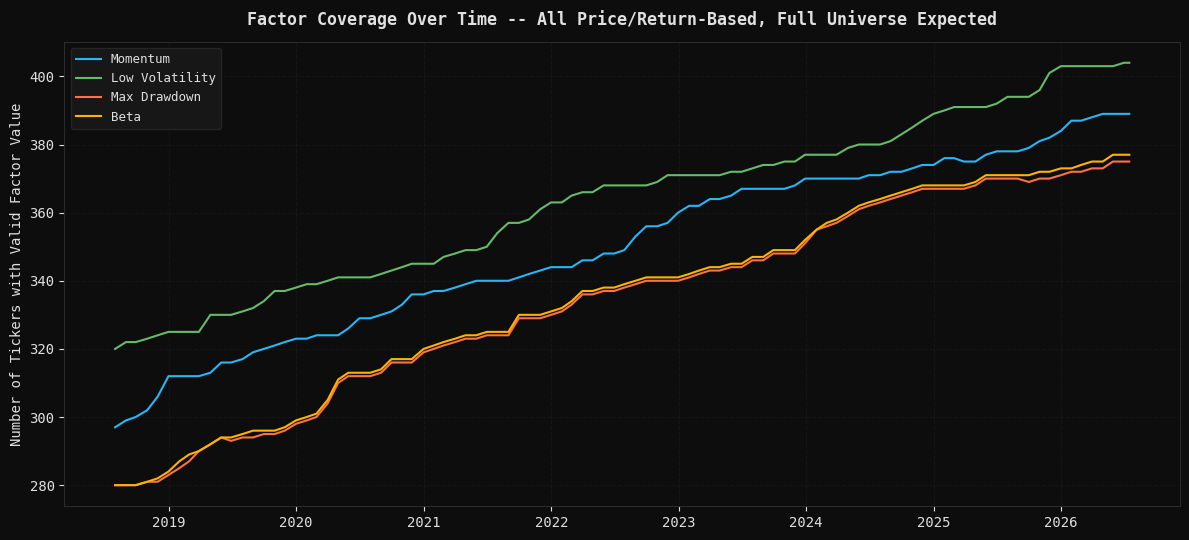

Saved -> .\output\02_factor_coverage_over_time.png


In [9]:
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(momentum_panel.notna().sum(axis=1), color=COLORS[0], linewidth=1.5, label='Momentum')
ax.plot(lowvol_panel.notna().sum(axis=1),   color=COLORS[2], linewidth=1.5, label='Low Volatility')
ax.plot(maxdd_panel.notna().sum(axis=1),    color=COLORS[1], linewidth=1.5, label='Max Drawdown')
ax.plot(beta_panel.notna().sum(axis=1),     color=COLORS[4], linewidth=1.5, label='Beta')
ax.set_title('Factor Coverage Over Time -- All Price/Return-Based, Full Universe Expected',
             fontsize=12, fontweight='bold', color=TEXT_COLOR, pad=12)
ax.set_ylabel('Number of Tickers with Valid Factor Value')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, '02_factor_coverage_over_time.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'Saved -> {path}')


Coverage rises from roughly 280 tickers (Momentum, Max Drawdown, Beta) and 320 (Low
Volatility) at the first rebalance date to 375–404 by the last, consistent with the expected
ramp-up: the 756-day factors start with the least coverage since they carry the longest history
requirement.

### Cross-Sectional Normalisation (Z-Score, Winsorised)

Every factor is converted to a cross-sectional z-score at each rebalance date independently (mean 0,
std 1 across that date's eligible universe), then clipped at $\pm 3.0$:

$$z_i(t) = \text{clip}\!\left(\frac{x_i(t) - \bar{x}(t)}{\sigma_x(t)},\ -3,\ 3\right)$$

`invert=True` negates the raw value before scoring — applied only to Low Volatility, since Momentum,
Maximum Drawdown (already signed "higher = smaller drawdown = better"), and the Beta-distance transform
are all already oriented "higher = better" before this step.

In [10]:
UNIVERSE_TICKERS = master_universe

def zscore_cross_section(panel, clip=Z_CLIP, invert=False):
    p = panel.reindex(columns=UNIVERSE_TICKERS)
    if invert:
        p = -p
    mean = p.mean(axis=1)
    std  = p.std(axis=1)
    z = p.sub(mean, axis=0).div(std, axis=0)
    return z.clip(lower=-clip, upper=clip)


# Beta is transformed to "distance from target" BEFORE z-scoring: closer to BETA_TARGET = higher score
beta_distance_panel = -(beta_panel - BETA_TARGET).abs()

momentum_z = zscore_cross_section(momentum_panel)
lowvol_z   = zscore_cross_section(lowvol_panel, invert=True)
maxdd_z    = zscore_cross_section(maxdd_panel)
beta_z     = zscore_cross_section(beta_distance_panel)

print('Normalisation complete.')
print(f'Momentum z coverage (last date): {momentum_z.iloc[-1].notna().sum()} / {len(UNIVERSE_TICKERS)}')
print(f'Low-Vol  z coverage (last date): {lowvol_z.iloc[-1].notna().sum()} / {len(UNIVERSE_TICKERS)}')
print(f'Max DD   z coverage (last date): {maxdd_z.iloc[-1].notna().sum()} / {len(UNIVERSE_TICKERS)}')
print(f'Beta     z coverage (last date): {beta_z.iloc[-1].notna().sum()} / {len(UNIVERSE_TICKERS)}')


Normalisation complete.
Momentum z coverage (last date): 389 / 404
Low-Vol  z coverage (last date): 404 / 404
Max DD   z coverage (last date): 375 / 404
Beta     z coverage (last date): 377 / 404


### Composite Score (40% / 20% / 20% / 20%, Locked Weights)

$$\text{CompositeScore}(t) = 0.40\,z_{\text{mom}}(t) + 0.20\,z_{\text{lowvol}}(t) +
0.20\,z_{\text{maxdd}}(t) + 0.20\,z_{\text{beta}}(t)$$

A stock's composite score is computed at a given rebalance date only if all four factor z-scores are
present — otherwise it is excluded from that date's ranking (not permanently; it can reappear once
sufficient trailing history accumulates).

In [11]:
composite_score = (
    FACTOR_WEIGHTS['momentum'] * momentum_z +
    FACTOR_WEIGHTS['low_vol']  * lowvol_z   +
    FACTOR_WEIGHTS['max_dd']   * maxdd_z    +
    FACTOR_WEIGHTS['beta']     * beta_z
)

all_four_present = (
    momentum_z.notna() & lowvol_z.notna() & maxdd_z.notna() & beta_z.notna()
)
composite_score = composite_score.where(all_four_present)

eligible_count = composite_score.notna().sum(axis=1)

print(f'Composite score panel shape: {composite_score.shape}')
print(f'Eligible stocks (all 4 factors present), first rebalance date : {eligible_count.iloc[0]}')
print(f'Eligible stocks (all 4 factors present), last  rebalance date : {eligible_count.iloc[-1]}')
print(f'Eligible stocks, median across all rebalance dates            : {eligible_count.median():.0f}')


Composite score panel shape: (97, 404)
Eligible stocks (all 4 factors present), first rebalance date : 280
Eligible stocks (all 4 factors present), last  rebalance date : 375
Eligible stocks, median across all rebalance dates            : 338


### Diagnostic: Eligible (Rankable) Universe Size Over Time

With all four factors price/return-based, eligible universe size is expected to stay close to full
universe size for almost the entire backtest, with a short ramp-up at the start while newly-tracked
stocks accumulate the 756-day history Maximum Drawdown/Beta require. A dip below 20 anywhere beyond
that initial ramp-up would indicate a risk of an under-sized Top-20 portfolio at that date.

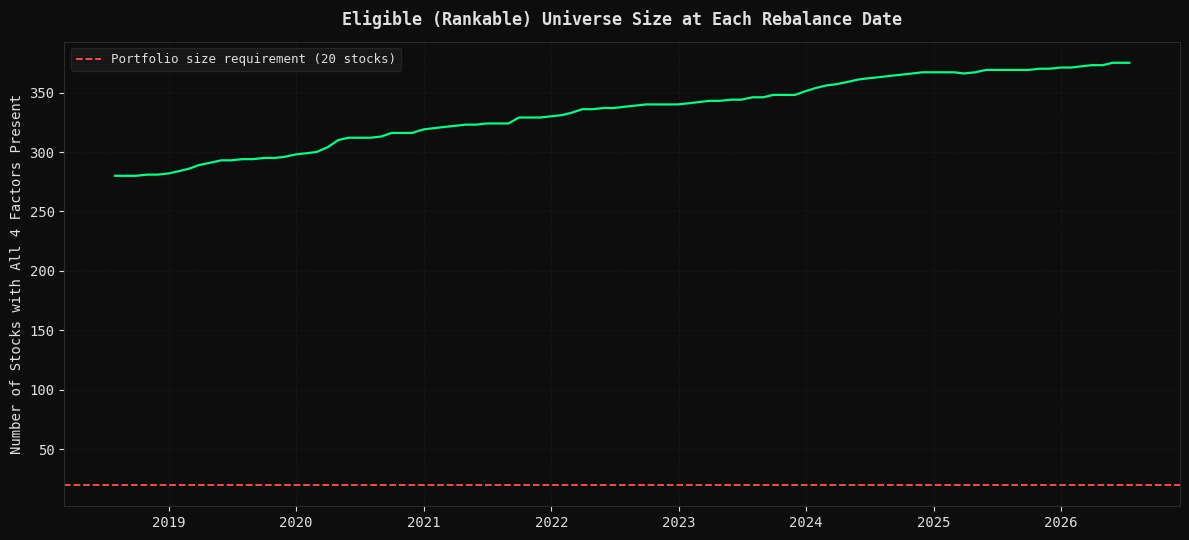

Saved -> .\output\02_eligible_universe_size.png

Every rebalance date has at least 20 eligible stocks -- no under-sized-portfolio risk.


In [12]:
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(eligible_count.index, eligible_count.values, color=ACCENT, linewidth=1.6)
ax.axhline(20, color=ACCENT2, linestyle='--', linewidth=1.3, label='Portfolio size requirement (20 stocks)')
ax.set_title('Eligible (Rankable) Universe Size at Each Rebalance Date',
             fontsize=12, fontweight='bold', color=TEXT_COLOR, pad=12)
ax.set_ylabel('Number of Stocks with All 4 Factors Present')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, '02_eligible_universe_size.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'Saved -> {path}')

n_below_20 = (eligible_count < 20).sum()
if n_below_20 > 0:
    print(f'\nNOTE: {n_below_20} / {len(eligible_count)} rebalance dates have fewer than 20 '
          f'eligible stocks. Check whether these cluster at the very start of the backtest '
          f'(expected ramp-up) or appear elsewhere (would need investigating).')
else:
    print('\nEvery rebalance date has at least 20 eligible stocks -- no under-sized-portfolio risk.')


Eligible universe size ranges from 280 (first rebalance date) to a median of 338 across
all 97 rebalance dates, with every date at or above the 20-stock minimum required for Notebook 03's
Top-20 selection — no under-sized-portfolio risk at any rebalance date in the backtest.

### Diagnostic: Factor Correlation Matrix (Pooled Across All Rebalance Dates)

Pairwise Pearson correlation of the four factor z-scores, pooled across all `(rebalance_date, ticker)`
observations. This diagnostic motivates the Design Rationale documented in the following section,
particularly the observed positive correlation between Low Volatility and Maximum Drawdown.

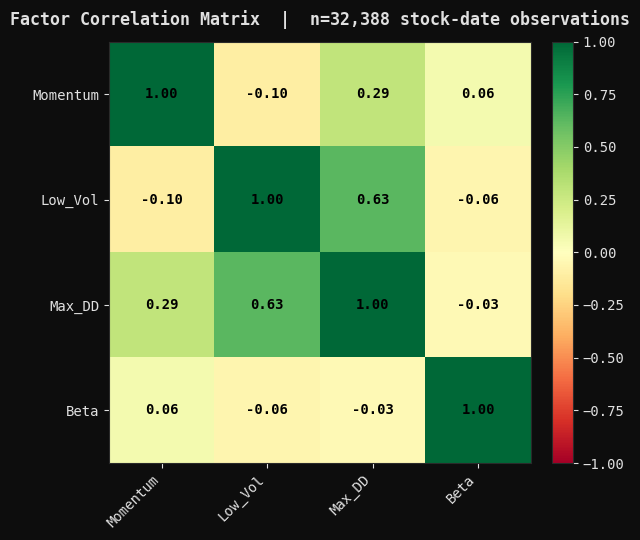

Saved -> .\output\02_factor_correlation_matrix.png

See "Design Rationale: Lookback Windows & Correlation Review" below for the documented assessment of this correlation structure -- in particular why Low Volatility vs Max Drawdown correlation is treated as an expected outcome rather than a flaw requiring correction.


In [13]:
factor_long = pd.DataFrame({
    'Momentum':  momentum_z.stack(),
    'Low_Vol':   lowvol_z.stack(),
    'Max_DD':    maxdd_z.stack(),
    'Beta':      beta_z.stack(),
}).dropna()

corr = factor_long.corr()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.columns))); ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center',
                color='black', fontsize=10, fontweight='bold')
ax.set_title(f'Factor Correlation Matrix  |  n={len(factor_long):,} stock-date observations',
             fontsize=12, fontweight='bold', color=TEXT_COLOR, pad=12)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, '02_factor_correlation_matrix.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'Saved -> {path}')
print(f'\nSee "Design Rationale: Lookback Windows & Correlation Review" below for the documented '
      f'assessment of this correlation structure -- in particular why Low Volatility vs Max Drawdown '
      f'correlation is treated as an expected outcome rather than a flaw requiring correction.')


The correlation matrix (previous cell) is the empirical basis for the design review
below — see in particular the discussion of Low Volatility vs. Maximum Drawdown correlation and why it
is treated as expected rather than a flaw.

## Design Decisions: Lookback Windows, Correlation Review, and Weighting Policy

This section documents a deliberate methodology review conducted during development, recorded here so
the reasoning behind each locked parameter is explainable on its own.

**Lookback window choice, factor by factor:**

- **Momentum (252d, 21-day skip):** the Jegadeesh–Titman 12-1 momentum specification — the most widely
  validated momentum construction in the academic and practitioner literature. Not revisited.
- **Low Volatility (252d):** kept deliberately shorter than Maximum Drawdown/Beta. Institutional
  low-volatility strategies commonly use a 1-year daily-volatility window (e.g., the S&P Low Volatility
  Index methodology). Keeping Low Volatility short and Maximum Drawdown long makes them measure
  genuinely different things — recent choppiness versus full-cycle severity — rather than the same risk
  dimension restated over an identical period.
- **Maximum Drawdown (756d, ~3yr):** a 1-year Maximum Drawdown is not a tail-risk measure but volatility
  restated, since most 1-year windows do not contain an actual crisis. Tail risk concerns rare, severe
  events, which requires a multi-year window for there to be a realistic chance one is captured. 756
  days is the practical floor for this, balanced against warm-up/data-availability cost (a 5-year window
  was considered and rejected — see below).
- **Beta (756d, ~3yr):** the rationale here is estimation noise rather than tail risk. A beta regression
  on 252 daily points has materially higher standard error than one on 756; more data reduces the
  influence of idiosyncratic day-to-day noise on the estimate. Since this factor's role is market
  exposure control — a stability objective, not an alpha-timing one — a noisy, rebalance-to-rebalance
  jumpy beta works against its purpose. This is broadly consistent with vendor conventions such as
  Bloomberg's standard beta (2 years of weekly data): different sampling frequency, same underlying
  preference for a multi-year window for estimation stability.

**Why 756 days and not 1,260 days (5yr) for Maximum Drawdown/Beta:** a longer window was evaluated and
rejected. Extending to 5 years would require pushing Notebook 01's warm-up period back further,
reducing early-period data availability for newer listings (shrinking the eligible universe precisely
when it is already thinnest) and increasing implementation complexity without a clearly justified
expected improvement over 756 days.

**Correlation review — Low Volatility vs. Maximum Drawdown:** the factor correlation review found a
meaningfully positive correlation between Low Volatility and Maximum Drawdown even after
differentiating their windows (252d vs. 756d). This is treated as an economically expected outcome, not
a methodology flaw. Some positive correlation between the two is structurally difficult to avoid: for
any return process, expected worst-case drawdown scales with volatility (loosely, on the order of
$\sigma\sqrt{T}$ under fairly general assumptions), so a persistently low-volatility stock will tend to
show a shallower drawdown by construction. Differentiating the lookback windows removes the avoidable
portion of the correlation — the part caused purely by measuring both factors over an identical period —
but a residual positive correlation was still expected. Momentum's positive correlation with Maximum
Drawdown is similarly expected (recent winners mechanically tend to show shallower recent drawdowns);
Beta's near-zero correlation with every other factor is the cleanest, most orthogonal result in the set.

**Decision: no orthogonalisation or residualisation.** Statistical decorrelation techniques
(orthogonalising Maximum Drawdown against Low Volatility, PCA-based recombination) were considered and
deliberately not applied. Priority was given to keeping each factor definition intuitive and
independently explainable over marginal gains in statistical orthogonality.

**Weighting policy: 40%/20%/20%/20%, locked by design intent, not optimised.** Momentum is deliberately
the primary alpha-generating factor; Low Volatility, Maximum Drawdown, and Beta are deliberately
complementary risk-control factors, weighted equally to each other. These weights were not derived from
any statistical procedure (risk parity, PCA-based effective-factor weighting, inverse-correlation
weighting) and were not tuned against backtest performance — they were set ex-ante from
portfolio-construction intent.

**Effective diversification versus the nominal 60% risk-control split:** because Low Volatility and
Maximum Drawdown carry meaningful correlation, the nominal 20%+20%+20% split across the three
risk-control factors somewhat overstates how many independent risk dimensions are actually being
controlled for; in effective-risk terms, the composite likely leans on fewer than three fully distinct
signals. This is disclosed as a known characteristic of the current design.

**No in-sample parameter optimisation, anywhere in this notebook.** Every lookback window, factor
weight, and scoring-direction choice (e.g., Beta scored via distance-from-1.0 rather than minimised) was
set from financial intuition and common quantitative-portfolio-management practice before any backtest
was run, never by searching over parameters for whichever choice produced the best historical
performance. Parameters tuned to fit history are liable to be overfit to that history, which would
undermine the credibility of performance results produced from Notebook 03 onward.

**Documented for future work (out of scope for this project):** alternative, statistically-driven
weighting methodologies — risk parity across factors, PCA-based effective-number-of-factors weighting,
or minimum-correlation portfolio construction over the factor scores themselves — are reasonable
extensions to revisit once this baseline framework has been fully validated.

### Diagnostic: Factor Score Distributions (Pooled)

Histograms of each factor's z-score distribution, pooled across all rebalance dates, as a sanity check
that winsorisation and cross-sectional normalisation produced the expected approximately-standard-normal
shape for each factor independently.

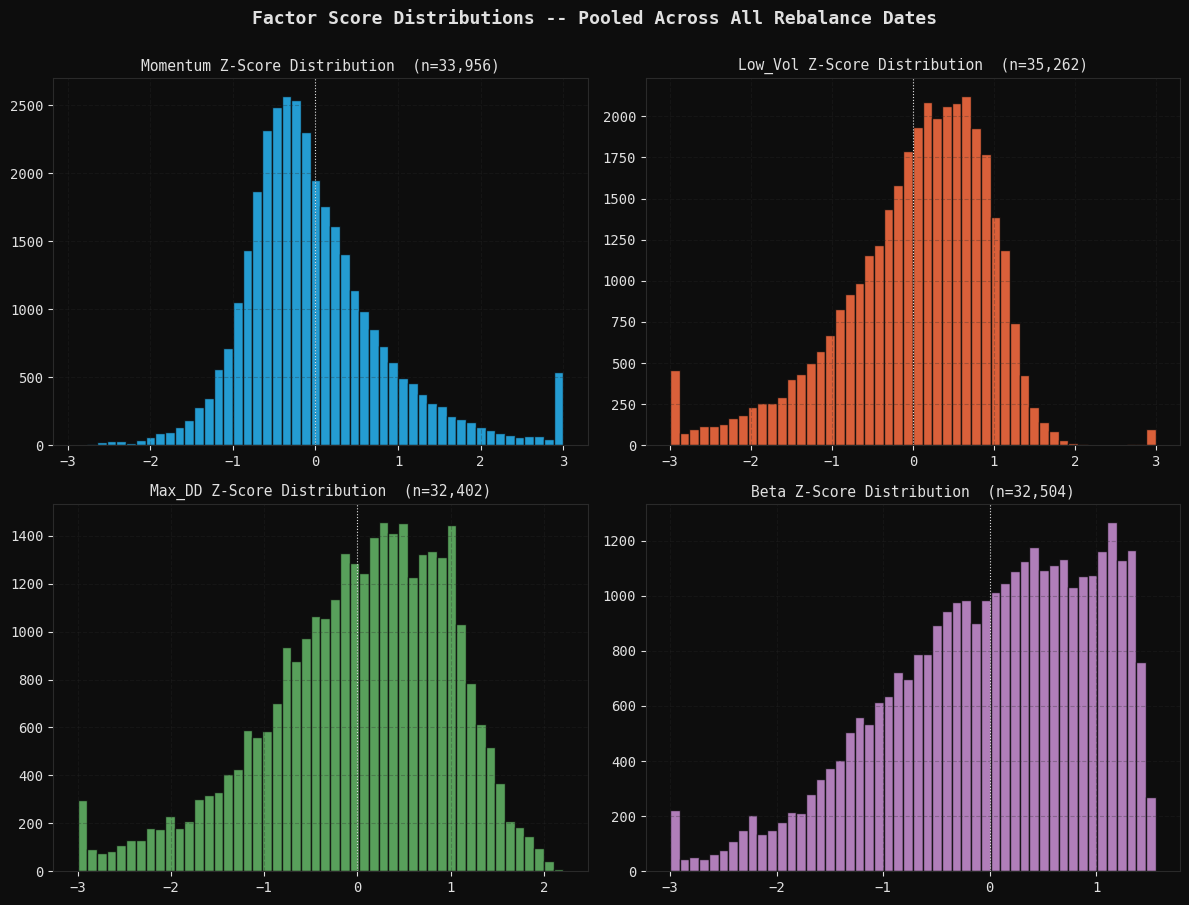

Saved -> .\output\02_factor_score_distributions.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
factor_panels = {
    'Momentum': momentum_z, 'Low_Vol': lowvol_z, 'Max_DD': maxdd_z, 'Beta': beta_z,
}
for ax, (name, panel) in zip(axes.flat, factor_panels.items()):
    vals = panel.stack().dropna()
    ax.hist(vals, bins=50, color=COLORS[list(factor_panels.keys()).index(name) % len(COLORS)],
            alpha=0.85, edgecolor=DARK_BG)
    ax.axvline(0, color=TEXT_COLOR, linewidth=0.8, linestyle=':')
    ax.set_title(f'{name} Z-Score Distribution  (n={len(vals):,})', fontsize=10.5, color=TEXT_COLOR)
    ax.grid(True, alpha=0.3)

fig.suptitle('Factor Score Distributions -- Pooled Across All Rebalance Dates',
             fontsize=13, fontweight='bold', color=TEXT_COLOR, y=1.00)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, '02_factor_score_distributions.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'Saved -> {path}')


### Save the Factor Panel and Diagnostics to data/

Persists the long-format factor panel — one row per `(rebalance_date, ticker)`, with all four z-scores,
raw (pre-z-score) Beta and Maximum Drawdown, and the composite score — plus the rebalance date grid and
eligible-universe-size series, all consumed by Notebook 03.

In [15]:
factor_panel_long = pd.DataFrame({
    'momentum_z':      momentum_z.stack(),
    'low_vol_z':       lowvol_z.stack(),
    'max_dd_z':        maxdd_z.stack(),
    'beta_z':          beta_z.stack(),
    'beta_raw':        beta_panel.reindex(columns=UNIVERSE_TICKERS).stack(),
    'max_dd_raw':      maxdd_panel.reindex(columns=UNIVERSE_TICKERS).stack(),
    'composite_score': composite_score.stack(),
}).reset_index()
factor_panel_long.columns = ['rebalance_date', 'ticker', 'momentum_z', 'low_vol_z', 'max_dd_z',
                              'beta_z', 'beta_raw', 'max_dd_raw', 'composite_score']

factor_panel_long.to_csv(os.path.join(DATA_DIR, 'factor_panel.csv'), index=False)
pd.Series(REBALANCE_DATES, name='rebalance_date').to_csv(
    os.path.join(DATA_DIR, 'rebalance_dates.csv'), index=False
)
eligible_count.rename('eligible_count').to_csv(os.path.join(DATA_DIR, 'eligible_universe_size.csv'))

print('Saved to data/:')
for f in ['factor_panel.csv', 'rebalance_dates.csv', 'eligible_universe_size.csv']:
    print(f'  {f}')

print()
print('=' * 60)
print('NOTEBOOK 02 (v2) -- COMPLETE')
print('=' * 60)
print(f'  Rebalance dates (monthly grid) : {len(REBALANCE_DATES)}')
print(f'  Universe                       : {len(UNIVERSE_TICKERS)} tickers')
print(f'  Median eligible stocks/date    : {eligible_count.median():.0f}')
print(f'  Factor weights                 : {FACTOR_WEIGHTS}')
print()
print('  Charts in output/:')
for f in ['02_factor_coverage_over_time.png', '02_eligible_universe_size.png',
          '02_factor_correlation_matrix.png', '02_factor_score_distributions.png']:
    print(f'    {f}')
print()
print('  Next -> Notebook 03: Portfolio Construction')


Saved to data/:
  factor_panel.csv
  rebalance_dates.csv
  eligible_universe_size.csv

NOTEBOOK 02 (v2) -- COMPLETE
  Rebalance dates (monthly grid) : 97
  Universe                       : 404 tickers
  Median eligible stocks/date    : 338
  Factor weights                 : {'momentum': 0.4, 'low_vol': 0.2, 'max_dd': 0.2, 'beta': 0.2}

  Charts in output/:
    02_factor_coverage_over_time.png
    02_eligible_universe_size.png
    02_factor_correlation_matrix.png
    02_factor_score_distributions.png

  Next -> Notebook 03: Portfolio Construction


---
## Results

- Rebalance grid: 97 month-end trading dates, 2018-07-31 → 2026-07-15.
- Factor coverage (of 404 universe tickers) rose from the first to the last rebalance date: Momentum
  297 → 389, Low Volatility 320 → 404, Maximum Drawdown 280 → 375, Beta 280 → 377.
- Eligible (all-four-factors-present) universe size: 280 at the first rebalance date, 375 at the last,
  median 338 across all 97 dates. Every rebalance date has at least the 20 stocks Notebook 03 requires
  for its Top-20 portfolio.
- Median Maximum Drawdown across the universe at the last rebalance date: −40.6%.
- Median Beta across the universe at the last rebalance date: 1.03.

## Interpretation

Coverage for all four factors converges toward the full universe size over the backtest window, with
the 756-day factors (Maximum Drawdown, Beta) trailing the 252-day factors (Momentum, Low Volatility) in
coverage throughout — consistent with the longer lookback's larger history requirement rather than any
data-quality issue. No rebalance date falls short of the 20-stock minimum, so eligible-universe size is
not a binding constraint on Notebook 03's portfolio construction at any point in the backtest.

## Key Findings

The v2 factor model achieves full price/return-based coverage without a fundamentals dependency, at the
cost of an approximately 3-year ramp-up in eligible universe size early in the backtest window (still
comfortably above the 20-stock floor throughout). The factor correlation review (Design Decisions,
above) confirms the expected structure: positive but not redundant correlation between Low Volatility
and Maximum Drawdown, and a near-orthogonal Beta factor — supporting the decision not to orthogonalise
or residualise the factor set.

## Limitations

- Quality and Value factors from the original project scope are not present in this notebook, due to
  yfinance's limited point-in-time fundamentals coverage (see Revision History above).
- The 20%/20%/20% nominal weighting across risk-control factors somewhat overstates effective
  diversification, given the disclosed Low Volatility/Maximum Drawdown correlation.
- No statistical weighting methodology (risk parity, PCA) was applied; weights are locked by design
  intent, not derived or optimised.

## Next Notebook

Notebook 03 (Portfolio Construction) consumes `data/factor_panel.csv` to rank stocks, select the Top-20
by composite score, and construct Equal Weight and True ERC portfolios across three rebalancing
frequencies.